In [2]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Reload and redo everything cleanly
df = pd.read_csv("Telco-Customer-Churn.csv")
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df = df.dropna(subset=['TotalCharges'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Confirm
print("Shape:", df.shape)
print("\nChurn value counts:")
print(df['Churn'].value_counts())
print("\nChurn rate:", round(df['Churn'].mean() * 100, 2), "%")

Shape: (7032, 21)

Churn value counts:
Churn
0    5163
1    1869
Name: count, dtype: int64

Churn rate: 26.58 %


C:\Users\srish\AppData\Local\Temp\ipykernel_18948\3317509661.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


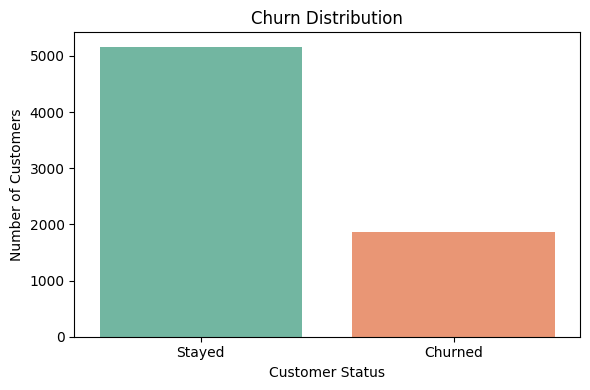

Stayed: 5163
Churned: 1869


In [5]:
# -----------------------------------
# EDA 1: Overall Churn Distribution
# -----------------------------------

plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution')
plt.xticks([0,1], ['Stayed', 'Churned'])
plt.xlabel('Customer Status')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print("Stayed:", df['Churn'].value_counts()[0])
print("Churned:", df['Churn'].value_counts()[1])

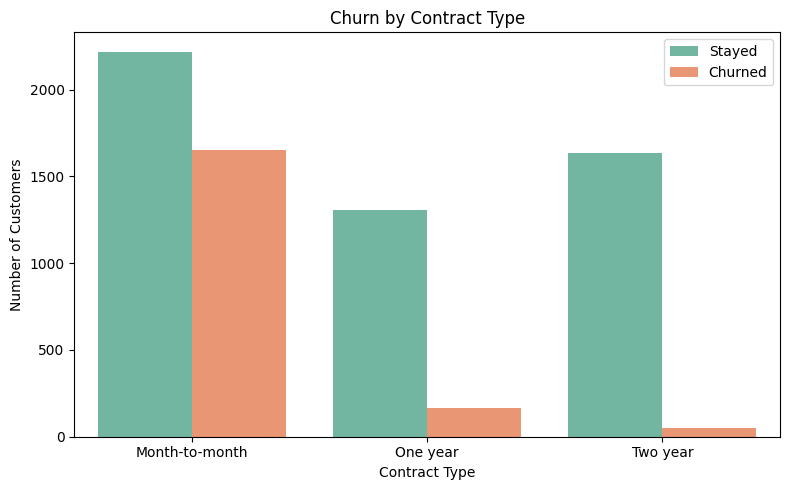

Churn rate by Contract Type:
Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Churn, dtype: float64


In [6]:
# -----------------------------------
# EDA 2: Churn by Contract Type
# -----------------------------------

plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

# Churn rate per contract type
print("Churn rate by Contract Type:")
print(round(df.groupby('Contract')['Churn'].mean() * 100, 2))

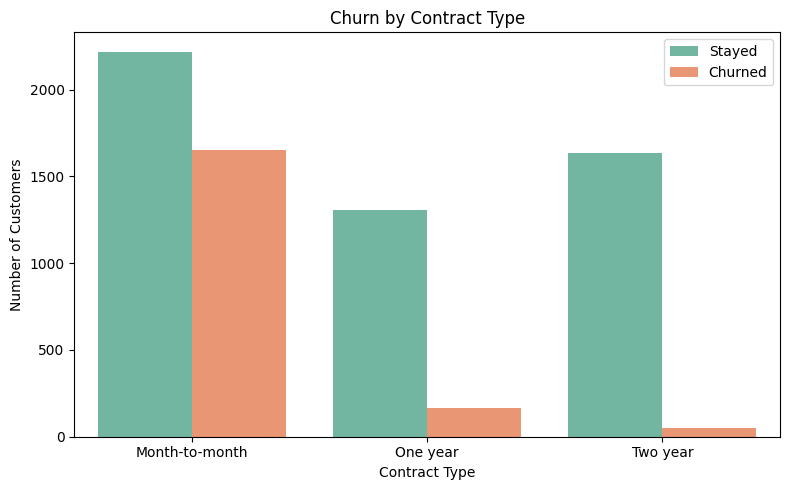

Churn rate by Contract Type:
Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Churn, dtype: float64


In [7]:
# -----------------------------------
# EDA 2: Churn by Contract Type
# -----------------------------------

plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

# Churn rate per contract type
print("Churn rate by Contract Type:")
print(round(df.groupby('Contract')['Churn'].mean() * 100, 2))

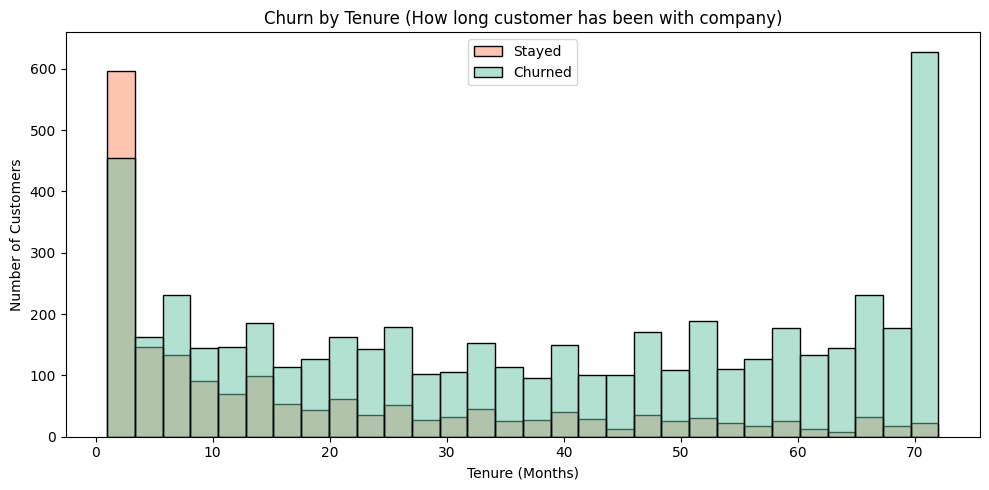

Average tenure of churned customers: 18.0 months
Average tenure of stayed customers: 37.7 months


In [8]:
# -----------------------------------
# EDA 3: Churn by Tenure
# -----------------------------------

plt.figure(figsize=(10,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette='Set2')
plt.title('Churn by Tenure (How long customer has been with company)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend(['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

print("Average tenure of churned customers:", round(df[df['Churn']==1]['tenure'].mean(), 1), "months")
print("Average tenure of stayed customers:", round(df[df['Churn']==0]['tenure'].mean(), 1), "months")

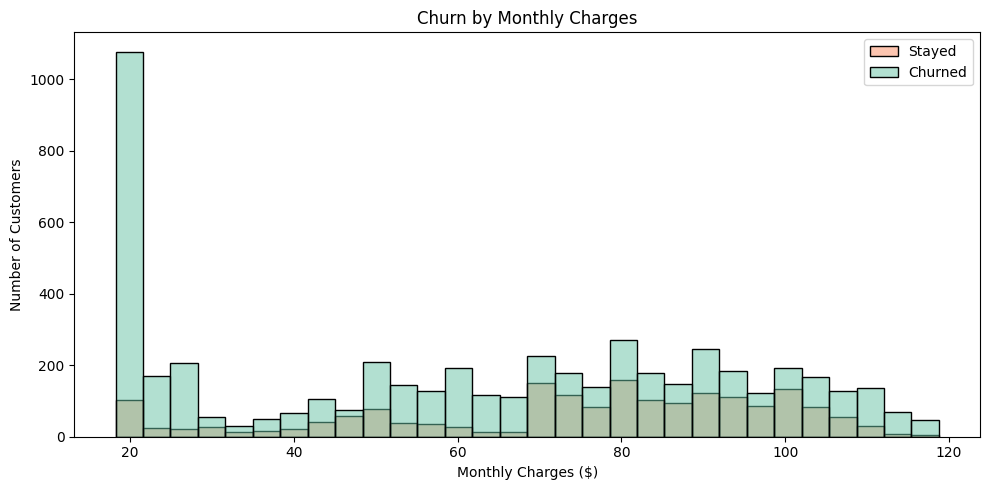

Average monthly charges - Churned: 74.44
Average monthly charges - Stayed: 61.31


In [9]:
# -----------------------------------
# EDA 4: Churn by Monthly Charges
# -----------------------------------

plt.figure(figsize=(10,5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, palette='Set2')
plt.title('Churn by Monthly Charges')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.legend(['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

print("Average monthly charges - Churned:", round(df[df['Churn']==1]['MonthlyCharges'].mean(), 2))
print("Average monthly charges - Stayed:", round(df[df['Churn']==0]['MonthlyCharges'].mean(), 2))

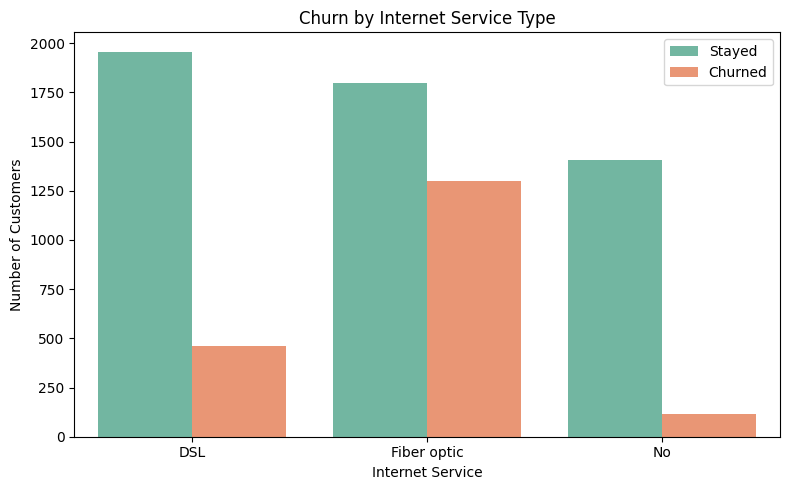

Churn rate by Internet Service:
InternetService
DSL            19.00
Fiber optic    41.89
No              7.43
Name: Churn, dtype: float64


In [10]:
# -----------------------------------
# EDA 5: Churn by Internet Service
# -----------------------------------

plt.figure(figsize=(8,5))
sns.countplot(x='InternetService', hue='Churn', data=df, palette='Set2')
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.legend(['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

print("Churn rate by Internet Service:")
print(round(df.groupby('InternetService')['Churn'].mean() * 100, 2))

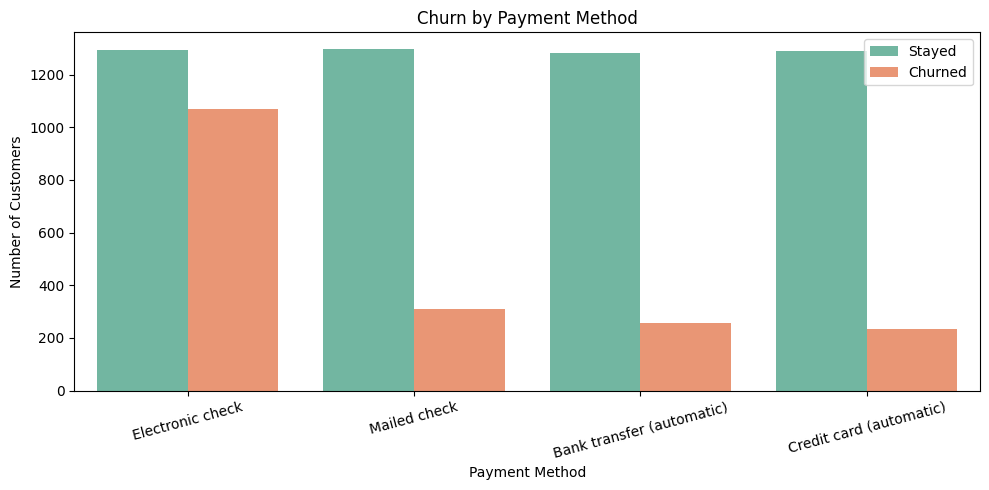

Churn rate by Payment Method:
PaymentMethod
Bank transfer (automatic)    16.73
Credit card (automatic)      15.25
Electronic check             45.29
Mailed check                 19.20
Name: Churn, dtype: float64


In [11]:
# -----------------------------------
# EDA 6: Churn by Payment Method
# -----------------------------------

plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='Set2')
plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.legend(['Stayed', 'Churned'])
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("Churn rate by Payment Method:")
print(round(df.groupby('PaymentMethod')['Churn'].mean() * 100, 2))

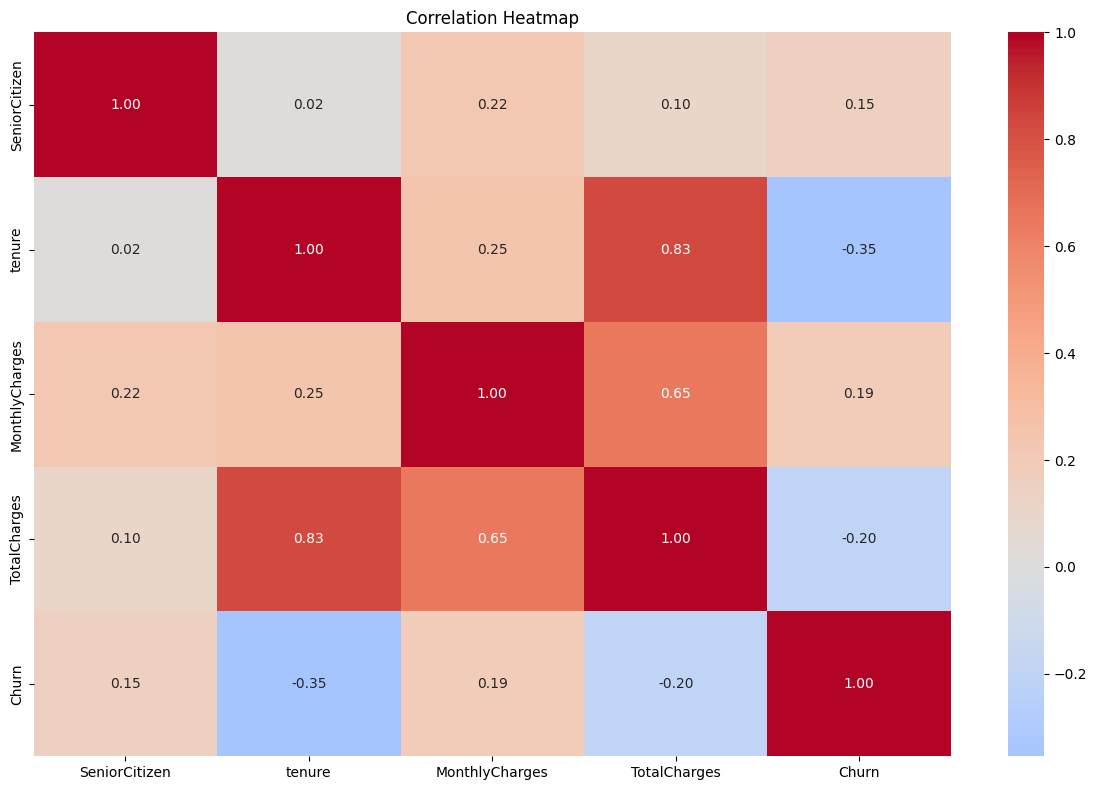

In [12]:
# -----------------------------------
# EDA 7: Correlation Heatmap
# -----------------------------------

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [13]:
# -----------------------------------
# PHASE 4: SQL ANALYSIS
# -----------------------------------

import sqlite3

# Create a database in memory
conn = sqlite3.connect('churn.db')

# Load our cleaned dataframe into SQL table
df.to_sql('customers', conn, if_exists='replace', index=False)

print("Data loaded into SQL successfully!")
print("Total rows in SQL table:", pd.read_sql("SELECT COUNT(*) FROM customers", conn).iloc[0,0])

Data loaded into SQL successfully!
Total rows in SQL table: 7032


In [14]:
# -----------------------------------
# SQL QUERY 1: Overall Churn Rate
# -----------------------------------

query1 = """
SELECT 
    COUNT(*) AS Total_Customers,
    SUM(Churn) AS Total_Churned,
    ROUND(AVG(Churn) * 100, 2) AS Churn_Rate_Percent
FROM customers
"""

result1 = pd.read_sql(query1, conn)
print("Overall Churn Rate:")
print(result1)

Overall Churn Rate:
   Total_Customers  Total_Churned  Churn_Rate_Percent
0             7032           1869               26.58


In [15]:
# -----------------------------------
# SQL QUERY 2: Churn by Contract Type
# -----------------------------------

query2 = """
SELECT 
    Contract,
    COUNT(*) AS Total_Customers,
    SUM(Churn) AS Churned,
    ROUND(AVG(Churn) * 100, 2) AS Churn_Rate_Percent
FROM customers
GROUP BY Contract
ORDER BY Churn_Rate_Percent DESC
"""

result2 = pd.read_sql(query2, conn)
print("Churn by Contract Type:")
print(result2)

Churn by Contract Type:
         Contract  Total_Customers  Churned  Churn_Rate_Percent
0  Month-to-month             3875     1655               42.71
1        One year             1472      166               11.28
2        Two year             1685       48                2.85


In [16]:
# -----------------------------------
# SQL QUERY 3: High Risk Customers
# -----------------------------------

query3 = """
SELECT 
    customerID,
    Contract,
    tenure,
    MonthlyCharges,
    InternetService,
    PaymentMethod,
    CASE 
        WHEN Contract = 'Month-to-month' 
         AND tenure < 12 
         AND MonthlyCharges > 65 
         AND InternetService = 'Fiber optic'
        THEN 'HIGH RISK'
        WHEN Contract = 'Month-to-month' 
         AND tenure < 24
        THEN 'MEDIUM RISK'
        ELSE 'LOW RISK'
    END AS Risk_Segment
FROM customers
WHERE Churn = 0
ORDER BY MonthlyCharges DESC
"""

result3 = pd.read_sql(query3, conn)
print("Risk Segments:")
print(result3['Risk_Segment'].value_counts())
print("\nSample High Risk Customers:")
print(result3[result3['Risk_Segment'] == 'HIGH RISK'].head(5))

Risk Segments:
Risk_Segment
LOW RISK       3769
MEDIUM RISK    1136
HIGH RISK       258
Name: count, dtype: int64

Sample High Risk Customers:
     customerID        Contract  tenure  MonthlyCharges InternetService  \
130  3292-PBZEJ  Month-to-month      11          111.40     Fiber optic   
279  5760-IFJOZ  Month-to-month       3          107.95     Fiber optic   
280  2081-VEYEH  Month-to-month       3          107.95     Fiber optic   
385  6734-GMPVK  Month-to-month       5          105.30     Fiber optic   
519  2018-PZKMU  Month-to-month       9          103.10     Fiber optic   

        PaymentMethod Risk_Segment  
130  Electronic check    HIGH RISK  
279      Mailed check    HIGH RISK  
280  Electronic check    HIGH RISK  
385  Electronic check    HIGH RISK  
519  Electronic check    HIGH RISK  


In [17]:
# -----------------------------------
# SQL QUERY 4: Revenue at Risk
# -----------------------------------

query4 = """
SELECT 
    CASE 
        WHEN Contract = 'Month-to-month' 
         AND tenure < 12 
         AND MonthlyCharges > 65 
         AND InternetService = 'Fiber optic'
        THEN 'HIGH RISK'
        WHEN Contract = 'Month-to-month' 
         AND tenure < 24
        THEN 'MEDIUM RISK'
        ELSE 'LOW RISK'
    END AS Risk_Segment,
    COUNT(*) AS Total_Customers,
    ROUND(AVG(MonthlyCharges), 2) AS Avg_Monthly_Charges,
    ROUND(SUM(MonthlyCharges), 2) AS Total_Monthly_Revenue_At_Risk
FROM customers
WHERE Churn = 0
GROUP BY Risk_Segment
ORDER BY Total_Monthly_Revenue_At_Risk DESC
"""

result4 = pd.read_sql(query4, conn)
print("Revenue at Risk by Segment:")
print(result4)

Revenue at Risk by Segment:
  Risk_Segment  Total_Customers  Avg_Monthly_Charges  \
0     LOW RISK             3769                64.23   
1  MEDIUM RISK             1136                47.28   
2    HIGH RISK              258                80.35   

   Total_Monthly_Revenue_At_Risk  
0                      242089.00  
1                       53710.35  
2                       20730.80  


In [18]:
# -----------------------------------
# SQL QUERY 5: Churn by Senior Citizen
# -----------------------------------

query5 = """
SELECT 
    CASE WHEN SeniorCitizen = 1 THEN 'Senior' ELSE 'Non-Senior' END AS Customer_Type,
    COUNT(*) AS Total_Customers,
    SUM(Churn) AS Churned,
    ROUND(AVG(Churn) * 100, 2) AS Churn_Rate_Percent,
    ROUND(AVG(MonthlyCharges), 2) AS Avg_Monthly_Charges
FROM customers
GROUP BY SeniorCitizen
ORDER BY Churn_Rate_Percent DESC
"""

result5 = pd.read_sql(query5, conn)
print("Churn by Customer Type:")
print(result5)

Churn by Customer Type:
  Customer_Type  Total_Customers  Churned  Churn_Rate_Percent  \
0        Senior             1142      476               41.68   
1    Non-Senior             5890     1393               23.65   

   Avg_Monthly_Charges  
0                79.82  
1                61.89  


In [19]:
# -----------------------------------
# PHASE 5: EXPORT FOR POWER BI
# -----------------------------------

# Add risk segment column to dataframe
df['Risk_Segment'] = 'LOW RISK'

df.loc[
    (df['Contract'] == 'Month-to-month') & 
    (df['tenure'] < 24), 
    'Risk_Segment'
] = 'MEDIUM RISK'

df.loc[
    (df['Contract'] == 'Month-to-month') & 
    (df['tenure'] < 12) & 
    (df['MonthlyCharges'] > 65) & 
    (df['InternetService'] == 'Fiber optic'), 
    'Risk_Segment'
] = 'HIGH RISK'

# Export to CSV
df.to_csv('churn_cleaned.csv', index=False)

print("File exported successfully!")
print("Shape:", df.shape)
print("\nRisk Segment Distribution:")
print(df['Risk_Segment'].value_counts())

File exported successfully!
Shape: (7032, 22)

Risk Segment Distribution:
Risk_Segment
LOW RISK       4359
MEDIUM RISK    1797
HIGH RISK       876
Name: count, dtype: int64
